## Variables
- $K$: number of trials
- $n_k$: count of successes in the $k$-th trial. $n_k \in \{0, 1\}$
- $p_k$: probability of success in the $k$-th trial
- $x_k$: latent learning process in the $k$-th trial
- $\mu$: probability of correct response in the absence of learning
- $\epsilon_k$: random noise in the latent learning process
- $\sigma_{\epsilon}$: standard deviation of the random noise, how rapidly the latent learning process changes from trial to trial
- $x_0$: initial value of the latent learning process, chosen to be uniform across choices
- $N_{1:K}$: number of trials up to the $K$-th trial


## Observation model
$$p(n_k \mid p_k, x_k) = p_k^{n_k} (1 - p_k)^{1-n_k}$$
where probability of success $p_k$ is determined by the latent learning process $x_k$ by a logistic function:
$$p_k = \frac{\exp (\mu + x_k)}{1 + \exp(\mu + x_k)} = \frac{1}{1 + \exp(-(\mu + x_k))} = sigmoid(\mu + x_k)$$

## Latent learning process
Random walk model:
$$ x_k = x_{k-1} + \epsilon_k $$
where $\epsilon_k \sim \mathcal{N}(0, \sigma_{\epsilon}^2)$

## Prior


$x_0 = 0$

$\mu = \log \left( \frac{p_0}{1-p_0} \right)$

## Estimate
- $x_k$: latent learning process
- $\mu$: probability of correct response in the absence of learning
- $\sigma_{\epsilon}$: standard deviation of the random noise

### Filter:
probability density for the correct response probability at trial $k$ given the data up to trial $k$:
$$
f(p \mid \mu, x_{k \mid k}, \sigma^2_{k \mid k}) = \frac{1}{\sqrt{2 \pi \sigma^2_{k \mid k}} p (1-p)} \exp \left( - \frac{ \left( \log \frac{p}{(1-p) \exp(\mu)} - x_{k \mid k} \right)^2}{2 \sigma^2_{k \mid k}} \right)
$$

Log-likelihood:
$$

\log f(p \mid \mu, x_{k \mid k}, \sigma^2_{k \mid k}) = - \frac{1}{2} \log(2 \pi \sigma^2_{k \mid k}) - \log(p (1-p)) - \frac{ \left( \log \frac{p}{(1-p) \exp(\mu)} - x_{k \mid k} \right)^2}{2 \sigma^2_{k \mid k}}
$$


Derivative of learning state process:
$$
x_{old} + \sigma^2_{old} \frac{N - N_{max} \exp(\mu + x)}{1 + \exp(\mu + x)} - x
$$

$$ x_{k \mid k-1} + \sigma^2_{k \mid k-1} \left[ n_k - \frac{\exp(\mu + x)}{ 1 + \exp(\mu + x)} \right] - x_{k \mid k}$$

In [21]:
import jax
import jax.numpy as jnp


from typing import Callable
import jax.scipy.optimize
from functools import partial
import numpy as np


def laplace_approximation(log_posterior_func: Callable, x0: jnp.ndarray) -> jnp.ndarray:
    neg_log_posterior = lambda x: -log_posterior_func(x)
    mode = jax.scipy.optimize.minimize(fun=neg_log_posterior, x0=x0, method="BFGS").x
    hessian = jax.hessian(neg_log_posterior)(mode)
    try:
        covariance = jnp.linalg.inv(hessian)
    except np.linalg.LinAlgError:
        try:
            covariance = jnp.linalg.pinv(hessian)
        except np.linalg.LinAlgError:
            return None, None

    return mode, covariance


@jax.jit
def log_state_space_pdf(x, x_old, sig_sq_old, is_success, N_max, mu):

    p = jax.nn.sigmoid(mu + x)
    return jnp.squeeze(
        jax.scipy.stats.norm.logpdf(
            x=x,
            loc=x_old,
            scale=jnp.sqrt(sig_sq_old),
        )
        + jax.scipy.stats.binom.logpmf(k=is_success, n=N_max, p=p)
    )


def smith_learning_filter(
    n_correct: jnp.ndarray,
    init_mode: float = None,
    init_variance: float = None,
    sigma_epsilon: float = jnp.sqrt(0.05),
    prob_correct_by_chance: float = 0.5,
    max_possible_correct: int = None,
) -> tuple[jnp.ndarray, jnp.ndarray]:
    """

    Parameters
    ----------
    n_correct : jnp.ndarray, shape (n_trials,)
    init_mode : float
    init_variance : float
    sigma_epsilon : float, optional
    prob_correct_by_chance : float, optional
    max_possible_correct : float, optional

    Returns
    -------
    posterior_mode : jnp.ndarray, shape (n_trials,)
    posterior_variance : jnp.ndarray, shape (n_trials,)
    """

    mu = jnp.log(prob_correct_by_chance / (1 - prob_correct_by_chance))
    sigma_squared_epsilon = sigma_epsilon**2

    # @jax.jit
    def _step(
        params_prev: tuple[float, float], args: tuple[jnp.ndarray, jnp.ndarray]
    ) -> tuple[tuple[jnp.ndarray, jnp.ndarray], tuple[jnp.ndarray, jnp.ndarray]]:

        mode_prev, variance_prev = params_prev
        n_correct_trial_k, max_possible_correct_trial_k = args

        # one step prediction
        one_step_mode = mode_prev
        one_step_variance = variance_prev + sigma_squared_epsilon

        log_objective_func = partial(
            log_state_space_pdf,
            x_old=one_step_mode,
            sig_sq_old=one_step_variance,
            is_success=n_correct_trial_k,
            N_max=max_possible_correct_trial_k,
            mu=mu,
        )
        posterior_mode, posterior_variance = laplace_approximation(
            log_objective_func, x0=jnp.array([one_step_mode])
        )
        posterior_mode = jnp.squeeze(posterior_mode)
        posterior_variance = jnp.squeeze(posterior_variance)

        return (posterior_mode, posterior_variance), (
            posterior_mode,
            posterior_variance,
            one_step_mode,
            one_step_variance,
        )

    if max_possible_correct is None:
        max_possible_correct = jnp.ones_like(n_correct) * n_correct.max()

    if init_mode is None:
        init_mode = 0.0
    if init_variance is None:
        init_variance = sigma_squared_epsilon

    posterior_mode, posterior_variance, one_step_mode, one_step_variance = jax.lax.scan(
        _step, (init_mode, init_variance), (n_correct, max_possible_correct)
    )[1]

    prob_success = jax.nn.sigmoid(mu + posterior_mode)

    return (
        prob_success,
        posterior_mode,
        posterior_variance,
        one_step_mode,
        one_step_variance,
    )


def smith_learning_smoother(
    filtered_posterior_mode,
    filtered_posterior_variance,
    one_step_mode,
    one_step_variance,
    prob_correct_by_chance: float = 0.5,
):
    def _step(params_prev, k):
        mode_smoothed_prev, variance_smoothed_prev = params_prev
        A_k = filtered_posterior_variance[k] / one_step_variance[k + 1]
        mode_smoothed = filtered_posterior_mode[k] + A_k * (
            mode_smoothed_prev - one_step_mode[k + 1]
        )
        variance_smoothed = filtered_posterior_variance[k] + A_k**2 * (
            variance_smoothed_prev - one_step_variance[k + 1]
        )

        return (mode_smoothed, variance_smoothed), (
            mode_smoothed,
            variance_smoothed,
            A_k,
        )

    init_params = (filtered_posterior_mode[-1], filtered_posterior_variance[-1])
    n_trials = len(filtered_posterior_mode)
    (_, _), (mode_smoothed, variance_smoothed, A) = jax.lax.scan(
        _step,
        init_params,
        jnp.arange(n_trials - 1),
        reverse=True,
    )

    mode_smoothed = jnp.concatenate([mode_smoothed, filtered_posterior_mode[-1:]])
    variance_smoothed = jnp.concatenate(
        [variance_smoothed, filtered_posterior_variance[-1:]]
    )

    mu = jnp.log(prob_correct_by_chance / (1 - prob_correct_by_chance))
    prob_success = jax.nn.sigmoid(mu + mode_smoothed)

    return mode_smoothed, variance_smoothed, prob_success, A

(0.0, 1.0)

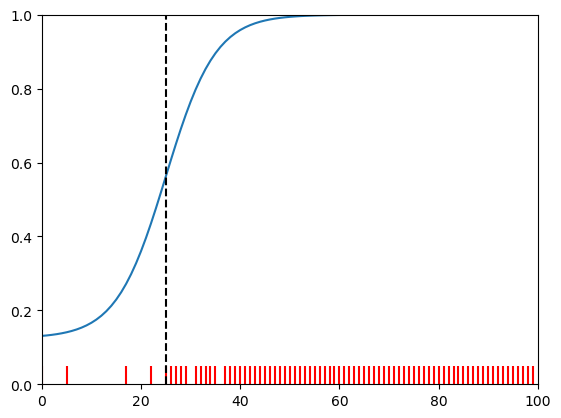

In [26]:
import numpy as np
import matplotlib.pyplot as plt


def simulate_data(
    n_trials=50,
    prob_success_init=0.125,
    prob_success_final=0.6,
    learning_rate=0.2,
    inflection_point=25,
):
    prob_success = prob_success_init + (prob_success_final - prob_success_init) / (
        1 + np.exp(-learning_rate * (np.arange(n_trials) - inflection_point))
    )
    rng = np.random.default_rng()

    return rng.binomial(1, prob_success), prob_success


is_correct, true_prob_success = simulate_data(
    n_trials=100,
    prob_success_init=0.125,
    prob_success_final=1.0,
    learning_rate=0.2,
    inflection_point=25,
)

plt.plot(true_prob_success)
plt.eventplot(is_correct.nonzero()[0], color="red", linelengths=0.1, lineoffsets=0.0)
plt.xlim(0, len(true_prob_success))
plt.axvline(25, color="black", linestyle="--", label="inflection point")
plt.ylim(0, 1)

Text(0, 0.5, 'Probability of success')

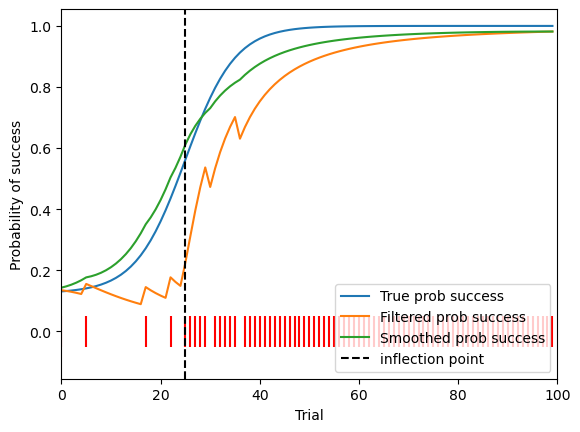

In [31]:
# sige = sqrt(0.005)
# sigsqguess = sige ^ 2
# muone = log(background_prob / (1 - background_prob))

prob_correct_by_chance = 0.125

(
    filtered_prob_success,
    filtered_posterior_mode,
    filtered_posterior_variance,
    one_step_mode,
    one_step_variance,
) = smith_learning_filter(
    n_correct=is_correct,
    sigma_epsilon=jnp.sqrt(0.05),
    prob_correct_by_chance=prob_correct_by_chance,
)

smoothed_mode, smoothed_variance, smoothed_prob_success, A = smith_learning_smoother(
    filtered_posterior_mode,
    filtered_posterior_variance,
    one_step_mode,
    one_step_variance,
    prob_correct_by_chance=prob_correct_by_chance,
)

plt.plot(true_prob_success, label="True prob success")
plt.plot(filtered_prob_success, label="Filtered prob success")
plt.plot(smoothed_prob_success, label="Smoothed prob success")
plt.eventplot(is_correct.nonzero()[0], color="red", linelengths=0.1, lineoffsets=0.0)
plt.axvline(25, color="black", linestyle="--", label="inflection point")
plt.xlim(0, len(true_prob_success))
plt.legend()
plt.xlabel("Trial")
plt.ylabel("Probability of success")
# plt.ylim(0, 1)

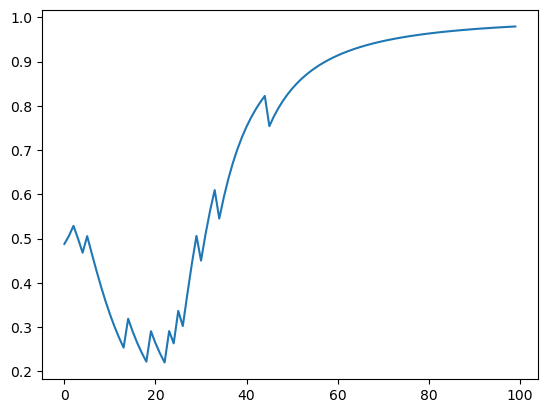

In [4]:
plt.plot(filtered_prob_success)

In [5]:
# %	initialcond = 0 specifies that the initial condition is fixed at the
# %			background probability
# %		      1 specifies that the initial condition should be
# %			estimated
# %		      2 removes xo from likelihood; anposcorrow strong bias
# sige = sqrt(0.005)
# sigsqguess = sige ^ 2
# q_guess = 0.0
# [p, q, s, qold, sold] = recfilter(I, sige, qguess, sigsqguess, muone);
# [qnew, signewsq, a]   = backest(q, qold, s, sold);
# if (startflag == 1)
#     qnew(1) = 0.5*qnew(2);   %updates the initial value of the latent process
#     signewsq(1) = sige^2;
# elseif(startflag == 0)
#     qnew(1) = 0;             %fixes initial value (no bias at anposcorr)
#     signewsq(1) = sige^2;
# elseif(startflag == 2)
#     qnew(1) = qnew(2);       %xo = x1 means no prior chance probability
#     signewsq(1) = signewsq(2);
# end
# [newsigsq(jk)]         = em_bino(I, qnew, signewsq, a, muone, startflag);


# qnew1save(jk) = qnew(1);

# %check for convergence
# if(jk>1)
#     a1 = abs(newsigsq(jk) - newsigsq(jk-1));
#     a2 = abs(qnew1save(jk) -qnew1save(jk-1));
#     if( a1 < cvgce_crit & a2 < cvgce_crit & startflag >= 1)
#         fprintf(2, 'EM estimates of RW variance and start point converged after %d steps   \n',  jk)
#         break
#     elseif ( a1 < cvgce_crit & startflag == 0)
#         fprintf(2, 'EM estimate of RW variance converged after %d steps   \n',  jk)
#         break
#     end
# end

# sige   = sqrt(newsigsq(jk));
# qguess = qnew(1);
# sigsqguess = signewsq(1);

In [6]:
def test_log_pdf(x, x_old, sig_sq_old):
    return jax.scipy.stats.norm.logpdf(
        x=x,
        loc=x_old,
        scale=jnp.sqrt(sig_sq_old),
    ).squeeze()


partial_test_log_pdf = partial(test_log_pdf, x_old=-5.0, sig_sq_old=15.0)


test_mode, test_var = laplace_approximation(partial_test_log_pdf, x0=jnp.array([3.0]))

test_mode, test_var

(Array([-5.0000005], dtype=float32), Array([[15.000001]], dtype=float32))

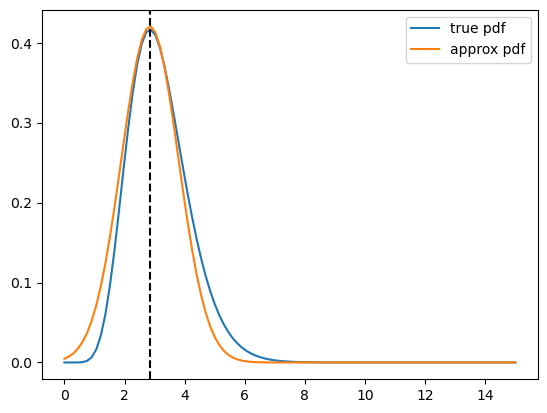

In [7]:
def test_log_pdf(x, x_old, sig_sq_old):
    return jax.scipy.stats.gamma.logpdf(
        x, a=x_old, scale=jnp.sqrt(sig_sq_old)
    ).squeeze()


partial_test_log_pdf = partial(test_log_pdf, x_old=10.0, sig_sq_old=0.1)

test_mode, test_var = laplace_approximation(partial_test_log_pdf, x0=jnp.array([10.0]))

x = jnp.linspace(0, 15, 100)

plt.plot(
    x,
    jnp.exp(partial_test_log_pdf(x)),
    label="true pdf",
)

plt.plot(
    x,
    jax.scipy.stats.norm.pdf(x, loc=test_mode, scale=jnp.sqrt(test_var)).squeeze(),
    label="approx pdf",
)
plt.legend()
plt.axvline(test_mode, color="black", linestyle="--")

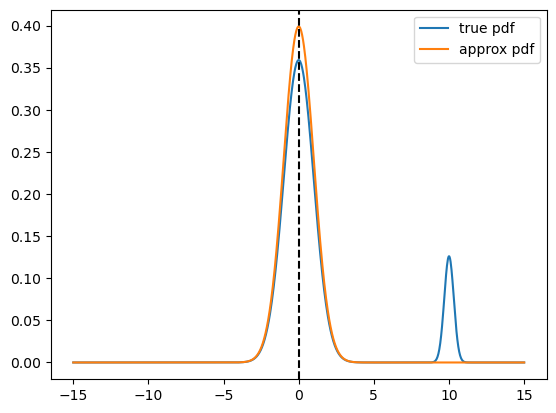

In [8]:
def test_log_pdf(x, x_old, sig_sq_old, mix_prob=0.1):
    return jnp.log(
        mix_prob * jax.scipy.stats.norm.pdf(x, loc=x_old, scale=jnp.sqrt(sig_sq_old))
        + (1 - mix_prob) * jax.scipy.stats.norm.pdf(x, loc=0.0, scale=1.0)
    ).squeeze()


partial_test_log_pdf = partial(test_log_pdf, x_old=10.0, sig_sq_old=0.1)

test_mode, test_var = laplace_approximation(partial_test_log_pdf, x0=jnp.array([5.0]))

x = jnp.linspace(-15, 15, 1000)

plt.plot(
    x,
    jnp.exp(partial_test_log_pdf(x)),
    label="true pdf",
)

plt.plot(
    x,
    jax.scipy.stats.norm.pdf(x, loc=test_mode, scale=jnp.sqrt(test_var)).squeeze(),
    label="approx pdf",
)
plt.legend()
plt.axvline(test_mode, color="black", linestyle="--")

In [9]:
import numpy as np
import sys

def forwardfilter(I, sigE, xguess, sigsqguess, mu):
    """
    Implements the forward recursive filtering algorithm to estimate the learning state
    (hidden process) at trial k as the Gaussian random variable with mean x{k|k} (xhat) and
    SIG^2{k|k} (sigsq).

    Parameters
    ----------
    I : ndarray
        Input array where the first row is the vector of number correct at each trial (N)
        and the second row is the total number that could be correct at each trial (Nmax).
    sigE : float
        Standard deviation of the process noise.
    xguess : float
        Initial guess for the state mean.
    sigsqguess : float
        Initial guess for the state variance.
    mu : float
        Parameter used in the observation model.

    Returns
    -------
    p : ndarray
        Observation model probability estimates.
    xhat : ndarray
        Posterior mode estimates.
    sigsq : ndarray
        Posterior variance estimates.
    xhatold : ndarray
        One-step prediction estimates of the mean.
    sigsqold : ndarray
        One-step prediction estimates of the variance.
    """

    K = I.shape[1]
    N = I[0, :]
    Nmax = I[1, :]

    xhat = np.zeros(K + 1)
    sigsq = np.zeros(K + 1)
    xhatold = np.zeros(K + 1)
    sigsqold = np.zeros(K + 1)
    number_fail = []

    # Initial conditions
    xhat[0] = xguess
    sigsq[0] = sigsqguess

    for k in range(1, K + 1):
        # One-step prediction
        xhatold[k] = xhat[k - 1]
        sigsqold[k] = sigsq[k - 1] + sigE**2

        # Posterior mode estimate using Newton's Method
        xhat[k], flagfail = newtonsolve(
            mu, xhatold[k], sigsqold[k], N[k - 1], Nmax[k - 1]
        )
        if flagfail > 0:
            number_fail.append(k)

        # Posterior variance estimate
        denom = (
            -1 / sigsqold[k]
            - Nmax[k - 1]
            * np.exp(mu)
            * np.exp(xhat[k])
            / (1 + np.exp(mu) * np.exp(xhat[k])) ** 2
        )
        sigsq[k] = -1 / denom

    if number_fail:
        print(f"Newton convergence failed at times {number_fail}", file=sys.stderr)

    # Observation model probability estimate
    p = np.exp(mu) * np.exp(xhat) / (1 + np.exp(mu) * np.exp(xhat))

    return p, xhat, sigsq, xhatold, sigsqold


def newtonsolve(mu, xold, sigoldsq, N, Nmax):
    """
    Implements Newton's Method to recursively estimate the posterior mode (x).

    Parameters
    ----------
    mu : float
        Parameter used in the observation model.
    xold : float
        Previous state mean estimate.
    sigoldsq : float
        Previous state variance estimate.
    N : int
        Number correct at the current trial.
    Nmax : int
        Total number that could be correct at the current trial.

    Returns
    -------
    x : float
        Posterior mode estimate.
    timefail : int
        Convergence failure flag (0 if successful, 1 if failed).
    """
    it = np.zeros(101)
    it[0] = xold + sigoldsq * (
        N - Nmax * np.exp(mu) * np.exp(xold) / (1 + np.exp(mu) * np.exp(xold))
    )

    for i in range(100):
        g = (
            xold
            + sigoldsq
            * (N - Nmax * np.exp(mu) * np.exp(it[i]) / (1 + np.exp(mu) * np.exp(it[i])))
            - it[i]
        )
        gprime = (
            -Nmax
            * sigoldsq
            * np.exp(mu)
            * np.exp(it[i])
            / (1 + np.exp(mu) * np.exp(it[i])) ** 2
            - 1
        )
        it[i + 1] = it[i] - g / gprime
        x = it[i + 1]

        if abs(x - it[i]) < 1e-10:
            return x, 0

    # Try new initial condition if first Newton's does not converge
    for initial_condition in [-1, 1]:
        it[0] = initial_condition
        for i in range(100):
            g = (
                xold
                + sigoldsq
                * (
                    N
                    - Nmax
                    * np.exp(mu)
                    * np.exp(it[i])
                    / (1 + np.exp(mu) * np.exp(it[i]))
                )
                - it[i]
            )
            gprime = (
                -Nmax
                * sigoldsq
                * np.exp(mu)
                * np.exp(it[i])
                / (1 + np.exp(mu) * np.exp(it[i])) ** 2
                - 1
            )
            it[i + 1] = it[i] - g / gprime
            x = it[i + 1]

            if abs(x - it[i]) < 1e-10:
                return x, 0

    print(
        f"Failed to converge after 3 attempts with initial condition {it[0]}",
        file=sys.stderr,
    )
    return x, 1

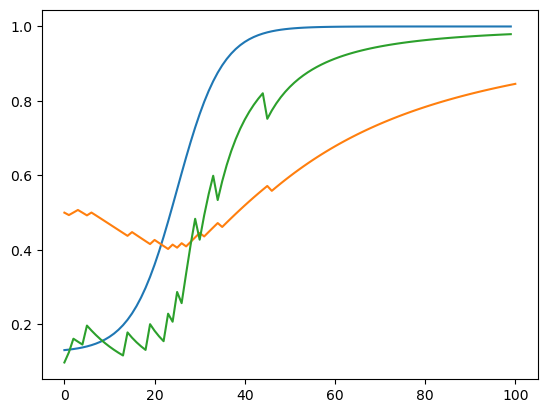

In [10]:
p, xhat, sigsq, xhatold, sigsqold = forwardfilter(
    np.array([is_correct, np.ones_like(is_correct) * is_correct.max()]),
    0.05,
    0.0,
    0.05,
    np.log(0.5 / (1 - 0.5)),
)

(
    filtered_prob_success,
    filtered_posterior_mode,
    filtered_posterior_variance,
    one_step_mode,
    one_step_variance,
) = smith_learning_filter(
    n_correct=is_correct,
    init_mode=0.0,
    init_variance=jnp.sqrt(0.05),
    sigma_epsilon=jnp.sqrt(0.05),
    prob_correct_by_chance=0.1,
)

plt.plot(true_prob_success)
plt.plot(p)
plt.plot(filtered_prob_success)